In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Charger le dataset
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Afficher les 5 premières lignes
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Understanding

In this section, we explore the structure of the dataset, the types of variables, missing values, and the distribution of the target variable `Churn`.


In [3]:
# Display all columns in the notebook
pd.set_option("display.max_columns", None)

# Display the first rows again
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset dimensions
df.shape

(7043, 21)

In [5]:
# List of columns
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [6]:
# General information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Descriptive statistics for numerical variables
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Descriptive statistics for categorical variables
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [9]:
# Missing values by column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# Number of unique values per column
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [11]:
# Target variable distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
# Target variable distribution in percentage
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Initial Observations

Each row represents a customer and each column describes customer demographic information, subscribed services, account information, billing details, and churn status.

The target variable is `Churn`, which indicates whether a customer left the company or not.

The first exploration step focuses on understanding the dataset structure, identifying numerical and categorical variables, checking missing values, and analyzing the distribution of the target variable.


## 2. Data Cleaning

In this section, we clean the dataset before building machine learning models.  

The main cleaning steps include converting `TotalCharges` to a numerical variable, handling missing values, encoding the target variable `Churn`, and removing the customer identifier.

In [13]:
# Create a copy of the original dataset
df_clean = df.copy()

In [14]:
# Convert TotalCharges from object to numeric
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

In [15]:
# Check missing values after converting TotalCharges
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
# Display rows with missing TotalCharges
df_clean[df_clean["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [17]:
# Remove rows with missing TotalCharges
df_clean = df_clean.dropna(subset=["TotalCharges"])

In [18]:
# New dataset shape after removing missing values
df_clean.shape

(7032, 21)

In [19]:
# Encode the target variable
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

In [20]:
# Check target variable after encoding
df_clean["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [21]:
# Remove customerID because it is only an identifier
df_clean = df_clean.drop(columns=["customerID"])

In [22]:
# Final cleaned dataset shape
df_clean.shape


(7032, 20)

In [23]:
# Check data types after cleaning
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [24]:
# Display first rows of cleaned dataset
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [25]:
# Reset index after removing rows
df_clean = df_clean.reset_index(drop=True)

### Cleaning Summary

The variable `TotalCharges` was converted from object type to numeric type.  
After conversion, 11 missing values were detected. These observations corresponded to customers with `tenure = 0`, meaning they were probably new customers without total billing history.

Since these observations represented a very small proportion of the dataset, they were removed.

The target variable `Churn` was encoded as follows:

- `No` was converted to `0`
- `Yes` was converted to `1`

The variable `customerID` was removed because it is only a unique identifier and does not provide useful predictive information.

## 3. Exploratory Data Analysis

In this section, we analyze the relationship between customer churn and several explanatory variables such as contract type, tenure, monthly charges, internet service, and payment method.

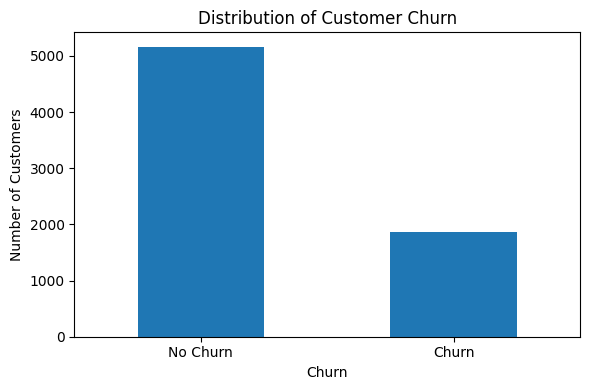

In [26]:
# Churn distribution
churn_counts = df_clean["Churn"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
churn_counts.plot(kind="bar")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(ticks=[0, 1], labels=["No Churn", "Churn"], rotation=0)
plt.tight_layout()
plt.savefig("../figures/churn_distribution.png")
plt.show()

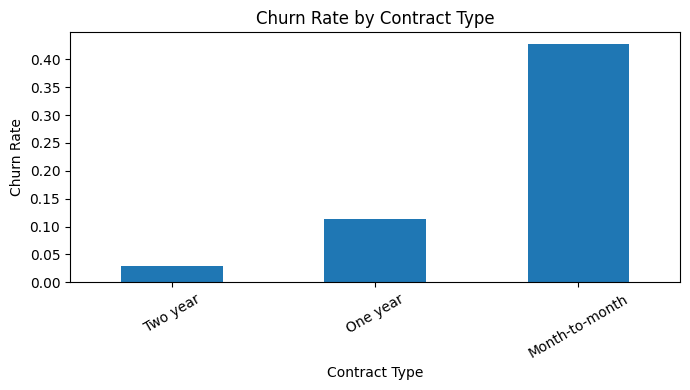

Contract
Two year          0.028487
One year          0.112772
Month-to-month    0.427097
Name: Churn, dtype: float64

In [27]:
# Churn rate by contract type
contract_churn = df_clean.groupby("Contract")["Churn"].mean().sort_values()

plt.figure(figsize=(7, 4))
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../figures/churn_by_contract.png")
plt.show()

contract_churn

<Figure size 700x400 with 0 Axes>

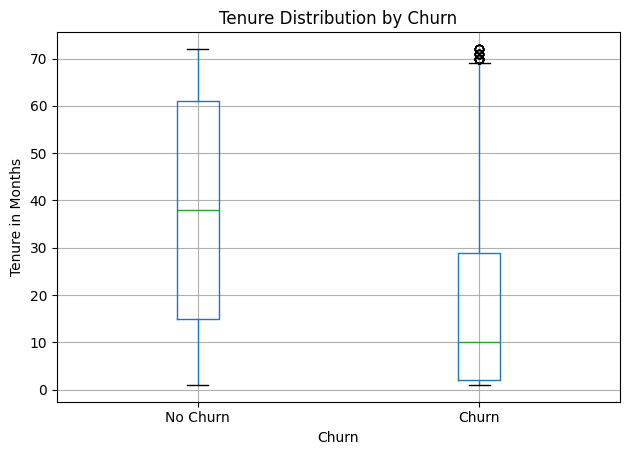

In [28]:
# Tenure distribution by churn
plt.figure(figsize=(7, 4))
df_clean.boxplot(column="tenure", by="Churn")
plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure in Months")
plt.xticks(ticks=[1, 2], labels=["No Churn", "Churn"])
plt.tight_layout()
plt.savefig("../figures/tenure_by_churn.png")
plt.show()

<Figure size 700x400 with 0 Axes>

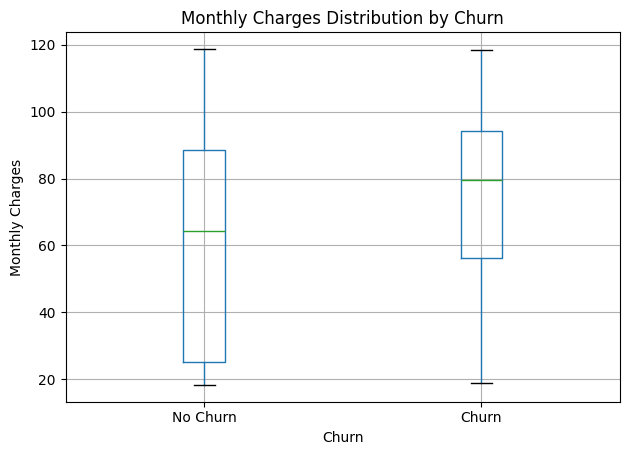

In [29]:
# Monthly charges distribution by churn
plt.figure(figsize=(7, 4))
df_clean.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.xticks(ticks=[1, 2], labels=["No Churn", "Churn"])
plt.tight_layout()
plt.savefig("../figures/monthly_charges_by_churn.png")
plt.show()

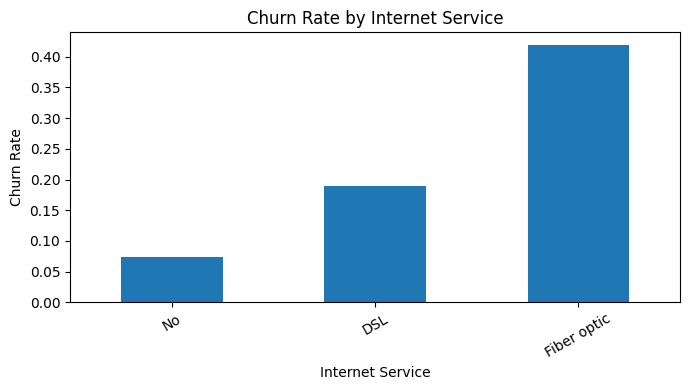

InternetService
No             0.074342
DSL            0.189983
Fiber optic    0.418928
Name: Churn, dtype: float64

In [30]:
# Churn rate by internet service
internet_churn = df_clean.groupby("InternetService")["Churn"].mean().sort_values()

plt.figure(figsize=(7, 4))
internet_churn.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../figures/churn_by_internet_service.png")
plt.show()

internet_churn

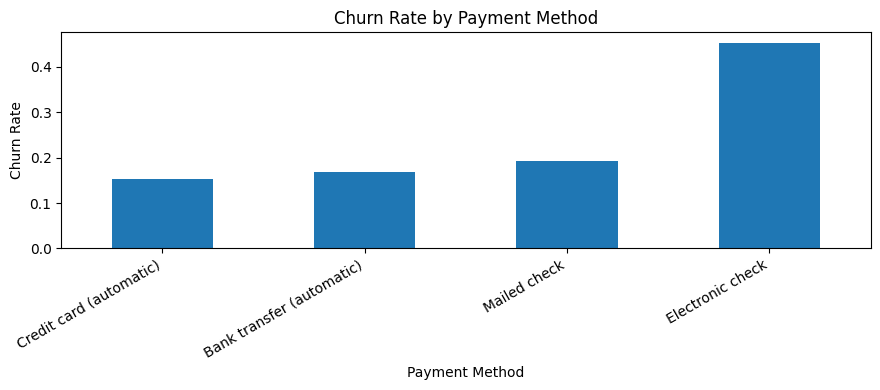

PaymentMethod
Credit card (automatic)      0.152531
Bank transfer (automatic)    0.167315
Mailed check                 0.192020
Electronic check             0.452854
Name: Churn, dtype: float64

In [31]:
# Churn rate by payment method
payment_churn = df_clean.groupby("PaymentMethod")["Churn"].mean().sort_values()

plt.figure(figsize=(9, 4))
payment_churn.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/churn_by_payment_method.png")
plt.show()

payment_churn

### Exploratory Analysis Summary

The exploratory analysis shows that customer churn is strongly associated with several customer characteristics.

First, the contract type appears to be one of the most important factors. Customers with month-to-month contracts have a much higher churn rate compared to customers with one-year or two-year contracts. This suggests that long-term contracts are associated with higher customer retention.

Second, customer tenure is strongly related to churn. Customers who churn tend to have lower tenure, indicating that newer customers are more likely to leave the company.

Third, customers with higher monthly charges appear to be more likely to churn. This may suggest price sensitivity or dissatisfaction with the perceived value of the service.

The analysis also shows that customers using fiber optic internet service have a higher churn rate than customers using DSL or no internet service. In addition, customers paying by electronic check have the highest churn rate among all payment methods.

These findings suggest that contract type, tenure, monthly charges, internet service, and payment method are important predictors for the machine learning model.

## 4. Data Preparation for Machine Learning

In this section, we prepare the dataset for machine learning.  
The target variable is separated from the explanatory variables, numerical and categorical features are identified, and the data is split into training and testing sets.

In [32]:
# Separate explanatory variables and target variable
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (7032, 19)
Shape of y: (7032,)


In [33]:
# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [34]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 19)
X_test shape: (1407, 19)
y_train shape: (5625,)
y_test shape: (1407,)


In [35]:
print("Churn distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nChurn distribution in test set:")
print(y_test.value_counts(normalize=True) * 100)

Churn distribution in training set:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Churn distribution in test set:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


### Data Preparation Summary

The cleaned dataset was divided into explanatory variables `X` and the target variable `y`.

The target variable is `Churn`, where:

- `0` represents customers who did not churn;
- `1` represents customers who churned.

After removing the target variable, the explanatory dataset contains 19 features.

The variables were separated into two groups:

- Numerical features: `SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges`;
- Categorical features: customer demographic variables, service-related variables, contract information, billing method, and payment method.

The dataset was then split into training and testing sets using an 80/20 split:

- 5625 observations were used for training;
- 1407 observations were used for testing.

The split was stratified using the target variable `Churn`, which preserved the same churn distribution in both training and testing sets.  
Both sets contain approximately 73.4% non-churn customers and 26.6% churn customers.

This ensures that the model will be trained and evaluated on datasets with similar class distributions.

## 5. Model Training and Evaluation

In this section, we build machine learning pipelines to predict customer churn.

The preprocessing step includes scaling numerical variables and encoding categorical variables.

Three classification models are trained and compared:

- Logistic Regression
- Random Forest
- Gradient Boosting

The models are evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Machine learning libraries imported successfully")

Machine learning libraries imported successfully


In [37]:
# Preprocessing for numerical variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical variables
try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", categorical_encoder)
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [38]:
# Define classification models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Models defined successfully")

Models defined successfully


In [39]:
# Train and evaluate models
results = []
trained_models = {}

for model_name, model in models.items():
    
    # Create a complete pipeline: preprocessing + model
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    clf.fit(X_train, y_train)
    
    # Predictions on the test set
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    # Store evaluation metrics
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    
    # Save trained model
    trained_models[model_name] = clf

# Convert results to DataFrame
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Gradient Boosting,0.796020,0.640777,0.529412,0.579795,0.838524
0,Logistic Regression,0.725657,0.490132,0.796791,0.606925,0.835134
1,Random Forest,0.783937,0.622378,0.475936,0.539394,0.811618


In [40]:
# Save model comparison results
results_df.to_csv("../model_results.csv", index=False)

print("Model results saved successfully")

Model results saved successfully


In [41]:
# Select the best model based on ROC-AUC
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: Gradient Boosting


Gradient Boosting gives the best overall ROC-AUC score, while Logistic Regression achieves the highest recall. If the business priority is to detect as many churn customers as possible, Logistic Regression may be preferred. If the objective is overall predictive performance, Gradient Boosting is selected as the best model.

### Model Training Summary

Three machine learning models were trained and compared: Logistic Regression, Random Forest, and Gradient Boosting.

The models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Gradient Boosting achieved the best overall performance based on ROC-AUC, with a score of approximately 0.839. This indicates that the model has a good ability to distinguish between churn and non-churn customers.

Logistic Regression achieved the highest recall, meaning that it was better at identifying customers who actually churned. This is important in a churn prediction problem, where detecting at-risk customers is often a business priority.

For the next evaluation step, Gradient Boosting is selected as the best model based on ROC-AUC.

## 6. Best Model Evaluation

In this section, the best model selected based on ROC-AUC is evaluated in more detail using the classification report, confusion matrix, and ROC curve.

In [42]:
# Predictions using the best model
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report for", best_model_name)
print(classification_report(y_test, y_pred_best))

Classification Report for Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



<Figure size 600x500 with 0 Axes>

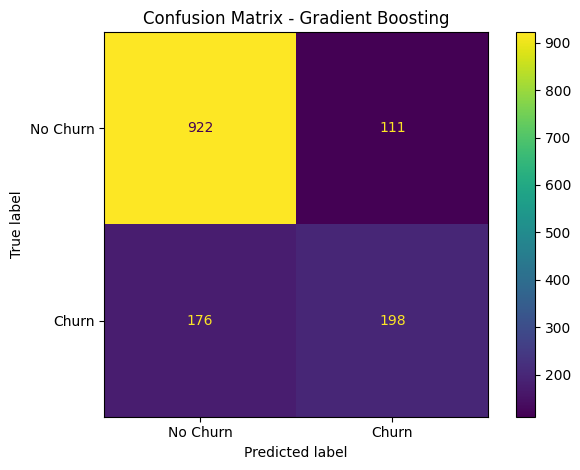

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["No Churn", "Churn"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix.png")
plt.show()

<Figure size 600x500 with 0 Axes>

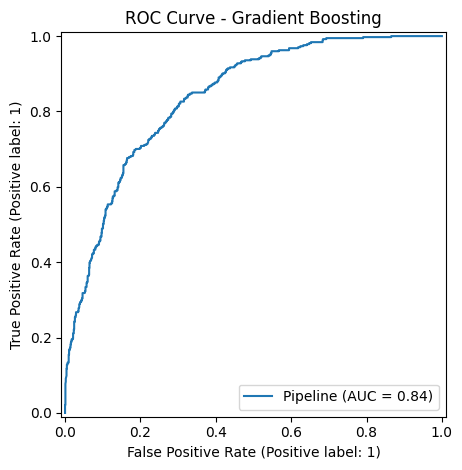

In [44]:
from sklearn.metrics import RocCurveDisplay

# ROC curve
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
plt.savefig("../figures/roc_curve.png")
plt.show()

### Best Model Evaluation Summary

The Gradient Boosting model was selected as the best model based on ROC-AUC.

The classification report provides detailed performance metrics for both classes: non-churn customers and churn customers.

The confusion matrix helps visualize correct and incorrect predictions, while the ROC curve shows the model's ability to distinguish between customers who churn and customers who do not churn.

This evaluation confirms whether the selected model is suitable for identifying customers at risk of churn.

### Best Model Evaluation Summary

The Gradient Boosting model was selected as the best model based on ROC-AUC.

The model achieved an accuracy of approximately 80% and a ROC-AUC score of approximately 0.84, indicating a good overall ability to distinguish between churn and non-churn customers.

For the non-churn class, the model performed well, with high precision and recall. However, for the churn class, the recall was lower, meaning that the model did not detect all customers who actually churned.

The confusion matrix shows that the model correctly classified 922 non-churn customers and 198 churn customers. However, it also misclassified 176 churn customers as non-churn.

From a business perspective, this means that the model can help identify at-risk customers, but further improvement may be needed if the main objective is to maximize the detection of churn customers.

## 7. Feature Importance

In this section, we analyze the most important variables used by the best model to predict customer churn.

Permutation importance is used to evaluate how much each feature contributes to the model's predictive performance.

In [45]:
from sklearn.inspection import permutation_importance

print("Permutation importance imported successfully")

Permutation importance imported successfully


In [46]:
from sklearn.inspection import permutation_importance

print("Permutation importance imported successfully")

Permutation importance imported successfully


In [47]:
# Compute permutation importance for the best model
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc"
)

# Create a DataFrame with feature importance
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
14,Contract,0.087548
4,tenure,0.047088
7,InternetService,0.016408
17,MonthlyCharges,0.013356
18,TotalCharges,0.010460
8,OnlineSecurity,0.005903
11,TechSupport,0.004646
16,PaymentMethod,0.003749
15,PaperlessBilling,0.003101
13,StreamingMovies,0.002158


In [48]:
# Top 10 most important features
top_features = importance_df.head(10)

top_features

,Feature,Importance
14,Contract,0.087548
4,tenure,0.047088
7,InternetService,0.016408
17,MonthlyCharges,0.013356
18,TotalCharges,0.010460
8,OnlineSecurity,0.005903
11,TechSupport,0.004646
16,PaymentMethod,0.003749
15,PaperlessBilling,0.003101
13,StreamingMovies,0.002158


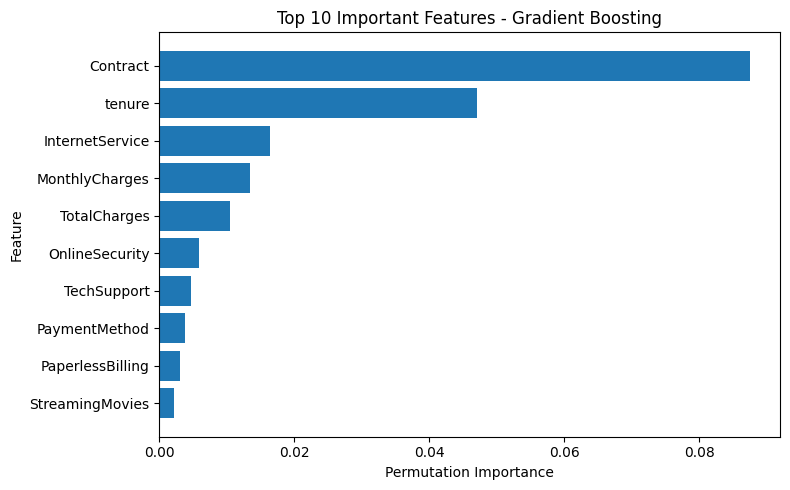

In [49]:
# Plot top 10 feature importance
top_features_plot = top_features.sort_values(by="Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features_plot["Feature"], top_features_plot["Importance"])
plt.title("Top 10 Important Features - Gradient Boosting")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../figures/feature_importance.png")
plt.show()

### Feature Importance Summary

The feature importance analysis shows that `Contract` is the most important variable for predicting customer churn. This result is consistent with the exploratory analysis, where customers with month-to-month contracts had the highest churn rate.

The second most important variable is `tenure`, which represents the number of months a customer has stayed with the company. Customers with lower tenure were more likely to churn, indicating that newer customers are more at risk.

Other important variables include `InternetService`, `MonthlyCharges`, `TotalCharges`, `OnlineSecurity`, `TechSupport`, and `PaymentMethod`.

These results confirm that churn is mainly influenced by contract type, customer loyalty, service type, billing amount, and service-related factors.

Some variables, such as `Partner`, `PhoneService`, `DeviceProtection`, and `Dependents`, have very low or slightly negative importance values. This suggests that they do not contribute much to the predictive performance of the model.

Overall, the feature importance results are consistent with the exploratory analysis and provide useful business insights for identifying customers at risk of churn.

## 8. General Conclusion

This project aimed to predict customer churn using supervised machine learning models.

The analysis started with data understanding and cleaning. The variable `TotalCharges` was converted to numeric format, missing values were handled, the target variable `Churn` was encoded, and the customer identifier was removed.

Exploratory data analysis showed that churn is strongly associated with several factors, including contract type, customer tenure, monthly charges, internet service, and payment method.

Three classification models were trained and compared: Logistic Regression, Random Forest, and Gradient Boosting. The Gradient Boosting model achieved the best overall ROC-AUC score, with an AUC of approximately 0.84.

The final evaluation showed that the model performs well in identifying non-churn customers and has a good overall ability to distinguish between churn and non-churn customers. However, the recall for churn customers remains moderate, which suggests that future improvements could focus on threshold tuning, hyperparameter optimization, or advanced models.

The feature importance analysis confirmed that the most influential variables are `Contract`, `tenure`, `InternetService`, `MonthlyCharges`, and `TotalCharges`.

Overall, this project demonstrates a complete machine learning workflow, including data cleaning, exploratory analysis, preprocessing, model training, model evaluation, and interpretation of results.